In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon", quiet=True)

# Import shared cleaning function from Functions/
sys.path.insert(0, "../..")
from Functions.text_preprocessing import apply_text_cleaning

BRONZE_DIR = Path("../../Data/1_Bronze/Reddit")
SILVER_DIR = Path("../../Data/2_Silver/Reddit")

In [ ]:
# Load raw combined posts from Bronze
df_raw = pd.read_parquet(BRONZE_DIR / "reddit_posts_raw.parquet")

# Apply text cleaning from Functions on the title column
df_combined = apply_text_cleaning(df_raw, text_col="title", output_col="text_clean")

# Add VADER sentiment on the original title
sia = SentimentIntensityAnalyzer()
df_combined["sentiment"] = df_combined["title"].apply(
    lambda t: sia.polarity_scores(str(t))["compound"]
)

# Parse timestamps
df_combined["date"] = pd.to_datetime(df_combined["created_utc"], unit="s", utc=True).dt.date
df_combined["date"] = pd.to_datetime(df_combined["date"])

print(df_combined.shape)
print(df_combined["subreddit_source"].value_counts())

In [ ]:
# Save cleaned posts to Silver
out = SILVER_DIR / "reddit_posts_clean.parquet"
df_combined.to_parquet(out, index=False)
print(f"Saved: {out}  ({df_combined.shape[0]:,} rows x {df_combined.shape[1]} columns)")

In [ ]:
# Read back from Silver for analysis
df_combined = pd.read_parquet(SILVER_DIR / "reddit_posts_clean.parquet")
print(df_combined[["title", "text_clean", "word_count"]].head(3))

# Descriptive setup (no train test split)

**Input:** `Data/1_Bronze/Reddit/reddit_comments_raw.parquet` · `reddit_posts_raw.parquet`


<!-- toc -->
## Contents
      - [Analyzing Review Length Distribution](#analyzing-review-length-distribution)
      - [Word Count Distribution](#word-count-distribution)
      - [Before vs. After Comparison](#before-vs-after-comparison)
      - [Creating the Document-Term Matrix with TF-IDF](#creating-the-document-term-matrix-with-tf-idf)
    - [SVD](#svd)
      - [Interpreting Latent Concepts](#interpreting-latent-concepts)
      - [Explained Variance](#explained-variance)
- [predictive setup --> create basetable for concatenation and feature engineering (train test split)](#predictive-setup----create-basetable-for-concatenation-and-feature-engineering-train-test-split)


#### Analyzing Review Length Distribution

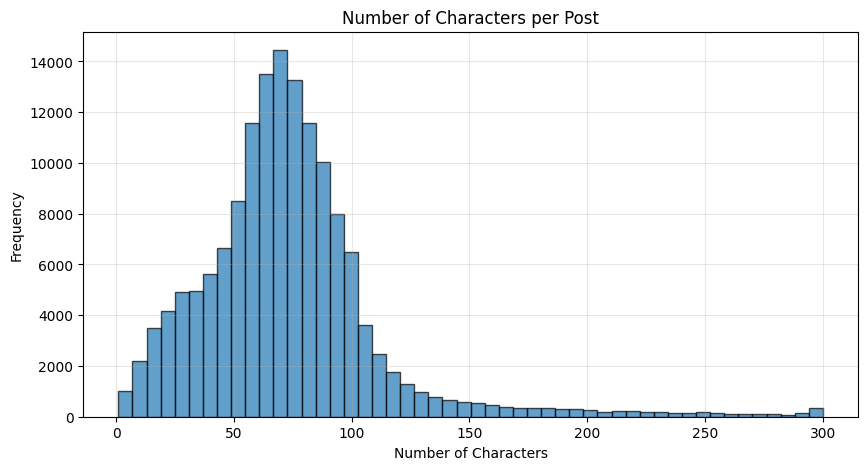

Average characters per post: 73.0
Median characters per post: 70.0


In [75]:
# Calculate character count for each review
char_counts = df_combined['title'].str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(char_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Number of Characters per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average characters per post: {char_counts.mean():.1f}")
print(f"Median characters per post: {char_counts.median():.1f}")

#### Word Count Distribution

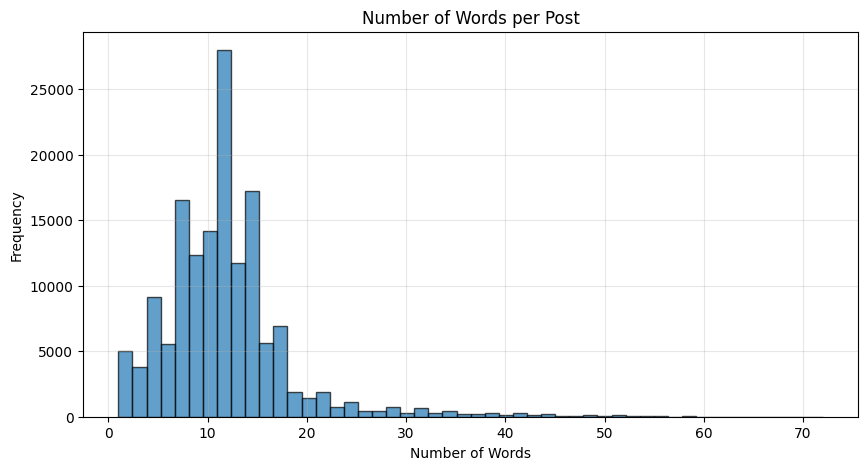

Average words per post: 11.8
Median words per post: 11.0


In [76]:
# Calculate word count for each review
word_counts = df_combined['title'].str.split().str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(word_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Number of Words per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average words per post: {word_counts.mean():.1f}")
print(f"Median words per post: {word_counts.median():.1f}")

#### Before vs. After Comparison

In [83]:
# Compare example review before and after preprocessing
idx = 20

print("="*80)
print("BEFORE PREPROCESSING:")
print("="*80)
print(df_combined['title'].iloc[idx][:200])

print("="*80)
print("AFTER PREPROCESSING:")
print("="*80)
print(df_combined['text_clean'].iloc[idx][:200])

BEFORE PREPROCESSING:
Supreme Court Justice Sotomayor Takes More Gifts Than Anyone Else
AFTER PREPROCESSING:
supreme court justice sotomayor takes gifts anyone else


#### Creating the Document-Term Matrix with TF-IDF

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── 1. Build TF-IDF vectorizer (following lecture parameters) ──
vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters (lecture default)
    lowercase=False,               # Already preprocessed
    max_features=None              # Keep all terms initially (lecture approach)
)

tfidf_matrix = vectorizer.fit_transform(df_combined['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"DTM shape: {tfidf_matrix.shape}")
print(f"Documents : {tfidf_matrix.shape[0]}")
print(f"Terms     : {tfidf_matrix.shape[1]}")
sparsity = (1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
print(f"Sparsity  : {sparsity:.1f}%")

# ── 2. Inspect a sample (first 5 docs × first 10 terms) ──
dtm_df = pd.DataFrame(
    tfidf_matrix[:5, :10].toarray(),
    columns=feature_names[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df)

DTM shape: (148582, 45013)
Documents : 148582
Terms     : 45013
Sparsity  : 100.0%

Sample TF-IDF Matrix:
        aa  aaa  aaaaaqdsikwksksksiasisiwismj  aaaahhh  aaand  aaj  aaja  \
Doc 1  0.0  0.0                           0.0      0.0    0.0  0.0   0.0   
Doc 2  0.0  0.0                           0.0      0.0    0.0  0.0   0.0   
Doc 3  0.0  0.0                           0.0      0.0    0.0  0.0   0.0   
Doc 4  0.0  0.0                           0.0      0.0    0.0  0.0   0.0   
Doc 5  0.0  0.0                           0.0      0.0    0.0  0.0   0.0   

       aalburg  aaloro  aamco  
Doc 1      0.0     0.0    0.0  
Doc 2      0.0     0.0    0.0  
Doc 3      0.0     0.0    0.0  
Doc 4      0.0     0.0    0.0  
Doc 5      0.0     0.0    0.0  


In [89]:
# Find which documents contain 'aaaaaand'
term_idx = list(feature_names).index('aaaaaqdsikwksksksiasisiwismj')
doc_indices = tfidf_matrix[:, term_idx].nonzero()[0]

print(f"'aaaaaqdsikwksksksiasisiwismj' appears in {len(doc_indices)} documents:")
for idx in doc_indices:
    print(f"\nDoc {idx}: {df_combined['title'].iloc[idx]}")

'aaaaaqdsikwksksksiasisiwismj' appears in 1 documents:

Doc 123776: PS5 survival game gains 860% more players after ditching PSslzlL888890 aaaaaqdsikwksksksiasisiwisMJ as djdjjsnsnsndns


### SVD

In [90]:
from sklearn.decomposition import TruncatedSVD

# Start with maximum possible components
# For TruncatedSVD: n_components < min(n_samples, n_features)
n_docs = tfidf_matrix.shape[0]
n_terms = tfidf_matrix.shape[1]
max_components = min(n_docs, n_terms) - 1

print(f"Original matrix shape: {tfidf_matrix.shape}")
print(f"Maximum components: {max_components}")

# Apply TruncatedSVD with all possible components
svd_full = TruncatedSVD(n_components=min(100, max_components), random_state=42)
documents_concepts_full = svd_full.fit_transform(tfidf_matrix)

print(f"\nReduced matrix shape: {documents_concepts_full.shape}")
print(f"Dimensionality reduction: {n_terms} → {documents_concepts_full.shape[1]}")

Original matrix shape: (148582, 45013)
Maximum components: 45012

Reduced matrix shape: (148582, 100)
Dimensionality reduction: 45013 → 100


In [91]:
# 1. U matrix (document-by-concept): returned by transform()
print("1. Document-by-Concept Matrix (U):")
print(f"   Shape: {documents_concepts_full.shape}")
print(f"   This is what we use as features for machine learning!")
print(f"\n   First 5 documents, first 5 concepts:")
print(documents_concepts_full[:5, :5])

# 2. Sigma (Σ): singular values (strength of each concept)
print("\n2. Singular Values (Σ - diagonal of sigma matrix):")
print(f"   Shape: {svd_full.singular_values_.shape}")
print(f"   First 10 values: {svd_full.singular_values_[:10]}")

# 3. V^T matrix (concept-by-term): components_
print("\n3. Concept-by-Term Matrix (V^T):")
print(f"   Shape: {svd_full.components_.shape}")
print(f"   Shows how terms contribute to each concept")

1. Document-by-Concept Matrix (U):
   Shape: (148582, 100)
   This is what we use as features for machine learning!

   First 5 documents, first 5 concepts:
[[ 1.79724976e-02 -3.79321901e-05  3.07378479e-03  1.67066489e-02
   4.81900645e-03]
 [ 3.15108534e-02 -1.33124633e-02  9.98091683e-02 -2.42188194e-02
   1.71748254e-02]
 [ 2.04748244e-02  6.18385832e-04  2.11402228e-03  8.92701010e-03
  -6.40522305e-03]
 [ 6.15463628e-03  2.06285186e-03  3.91199761e-03  1.91127245e-02
  -2.39058787e-03]
 [ 5.02680743e-02 -3.89994290e-03  1.12105929e-01  2.37266894e-02
  -3.25251193e-03]]

2. Singular Values (Σ - diagonal of sigma matrix):
   Shape: (100,)
   First 10 values: [36.12800751 27.15271734 24.93193249 20.97910517 20.32542054 19.76239195
 18.28126223 17.80151542 17.6942516  17.23769728]

3. Concept-by-Term Matrix (V^T):
   Shape: (100, 45013)
   Shows how terms contribute to each concept


#### Interpreting Latent Concepts

Each component represents a latent semantic concept. Let's examine which terms are most strongly associated with the first few concepts:

In [92]:
def display_top_terms_per_concept(svd_model, feature_names, n_top=10, n_concepts=5):
    """Display top terms for each latent concept."""
    for i in range(min(n_concepts, svd_model.n_components)):
        # Get component weights for all terms
        component = svd_model.components_[i]
        
        # Get indices of top terms (by absolute value)
        top_indices = np.argsort(np.abs(component))[::-1][:n_top]
        top_terms = [feature_names[idx] for idx in top_indices]
        top_weights = [component[idx] for idx in top_indices]
        
        print(f"\nConcept {i+1} (σ = {svd_full.singular_values_[i]:.3f}):")
        for term, weight in zip(top_terms, top_weights):
            print(f"  {term:20s} {weight:>8.4f}")

display_top_terms_per_concept(svd_full, feature_names, n_top=10, n_concepts=2)


Concept 1 (σ = 36.128):
  trump                  0.6028
  harris                 0.4535
  kamala                 0.3428
  donald                 0.1897
  biden                  0.1810
  election               0.1197
  says                   0.1078
  president              0.1075
  campaign               0.1052
  debate                 0.1008

Concept 2 (σ = 27.153):
  trump                  0.6029
  kamala                -0.5259
  harris                -0.4877
  donald                 0.1746
  rally                  0.1007
  biden                 -0.0979
  assassination          0.0842
  attempt                0.0726
  walz                  -0.0577
  endorses              -0.0537


#### Explained Variance

The singular values tell us how much variance each component captures. We can use this to decide how many components to keep:

In [93]:
# Calculate variance explained by each component
# Variance is proportional to squared singular values
variance = svd_full.singular_values_ ** 2

# Calculate percentage of variance explained
total_variance = np.sum(variance)
explained_variance_ratio = variance / total_variance

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Variance Explained:")
print(f"{'Component':<12} {'Variance':<12} {'% Explained':<15} {'Cumulative %':<15}")
print("-" * 60)
for i in range(min(10, len(explained_variance_ratio))):
    print(f"{i+1:<12} {variance[i]:<12.4f} {explained_variance_ratio[i]*100:<15.2f} {cumulative_variance[i]*100:<15.2f}")

print(f"\nFirst 3 components explain {cumulative_variance[2]*100:.1f}% of variance")
print(f"First 5 components explain {cumulative_variance[4]*100:.1f}% of variance")

Variance Explained:
Component    Variance     % Explained     Cumulative %   
------------------------------------------------------------
1            1305.2329    6.60            6.60           
2            737.2701     3.73            10.33          
3            621.6013     3.14            13.47          
4            440.1229     2.23            15.70          
5            413.1227     2.09            17.79          
6            390.5521     1.98            19.76          
7            334.2045     1.69            21.45          
8            316.8940     1.60            23.06          
9            313.0865     1.58            24.64          
10           297.1382     1.50            26.14          

First 3 components explain 13.5% of variance
First 5 components explain 17.8% of variance


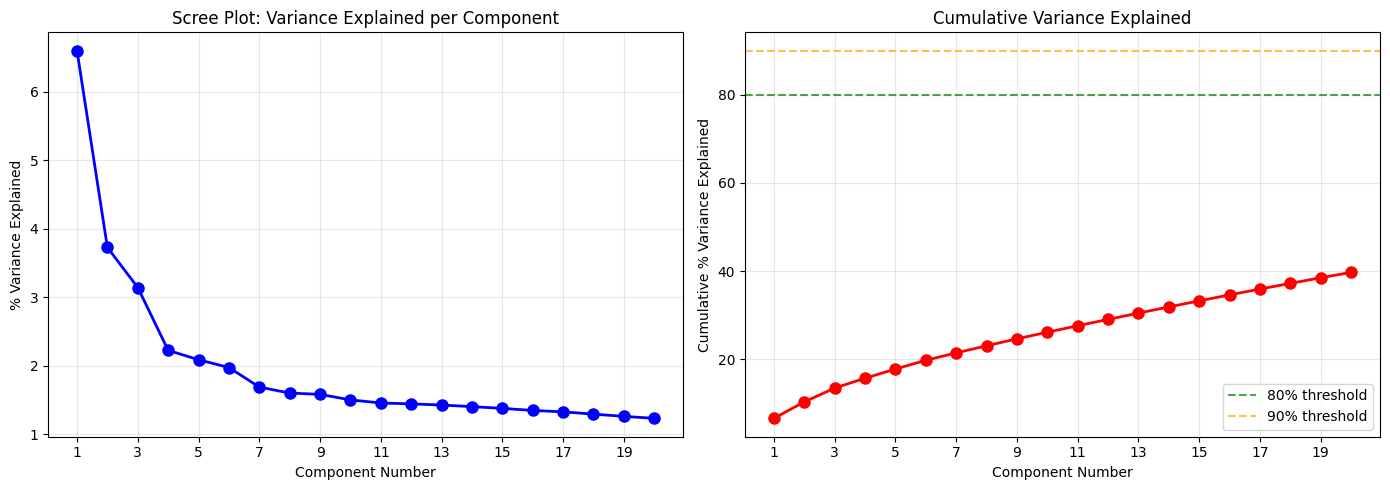

80% variance explained with 67 components
90% variance explained with 83 components
95% variance explained with 91 components


In [94]:
# Create scree plot
n_components_to_plot = min(20, len(explained_variance_ratio))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Variance explained per component
ax1.plot(range(1, n_components_to_plot + 1), 
         explained_variance_ratio[:n_components_to_plot] * 100, 
         'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Component Number')
ax1.set_ylabel('% Variance Explained')
ax1.set_title('Scree Plot: Variance Explained per Component')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, n_components_to_plot + 1, 2))

# Plot 2: Cumulative variance explained
ax2.plot(range(1, n_components_to_plot + 1), 
         cumulative_variance[:n_components_to_plot] * 100, 
         'ro-', linewidth=2, markersize=8)
ax2.axhline(y=80, color='green', linestyle='--', label='80% threshold', alpha=0.7)
ax2.axhline(y=90, color='orange', linestyle='--', label='90% threshold', alpha=0.7)
ax2.set_xlabel('Component Number')
ax2.set_ylabel('Cumulative % Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, n_components_to_plot + 1, 2))

plt.tight_layout()
plt.show()

# Find number of components for common thresholds
for threshold in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained with {n_comp} components")

In [95]:
# Create LSA model with optimal number of components
# Let's choose enough components to explain ~80% of variance
n_components_optimal = np.argmax(cumulative_variance >= 0.80) + 1

print(f"Using {n_components_optimal} components (explains {cumulative_variance[n_components_optimal-1]*100:.1f}% of variance)")

# Fit LSA model with reduced dimensionality
lsa = TruncatedSVD(n_components=n_components_optimal, random_state=42)
documents_lsa = lsa.fit_transform(tfidf_matrix)

print(f"\nOriginal dimensionality: {tfidf_matrix.shape[1]} terms")
print(f"Reduced dimensionality: {documents_lsa.shape[1]} concepts")
print(f"Dimensionality reduction: {(1 - documents_lsa.shape[1]/tfidf_matrix.shape[1])*100:.1f}%")

Using 67 components (explains 80.0% of variance)

Original dimensionality: 45013 terms
Reduced dimensionality: 67 concepts
Dimensionality reduction: 99.9%


In [96]:
documents_lsa.shape

(148582, 67)

In [97]:
df_combined.shape

(148582, 12)

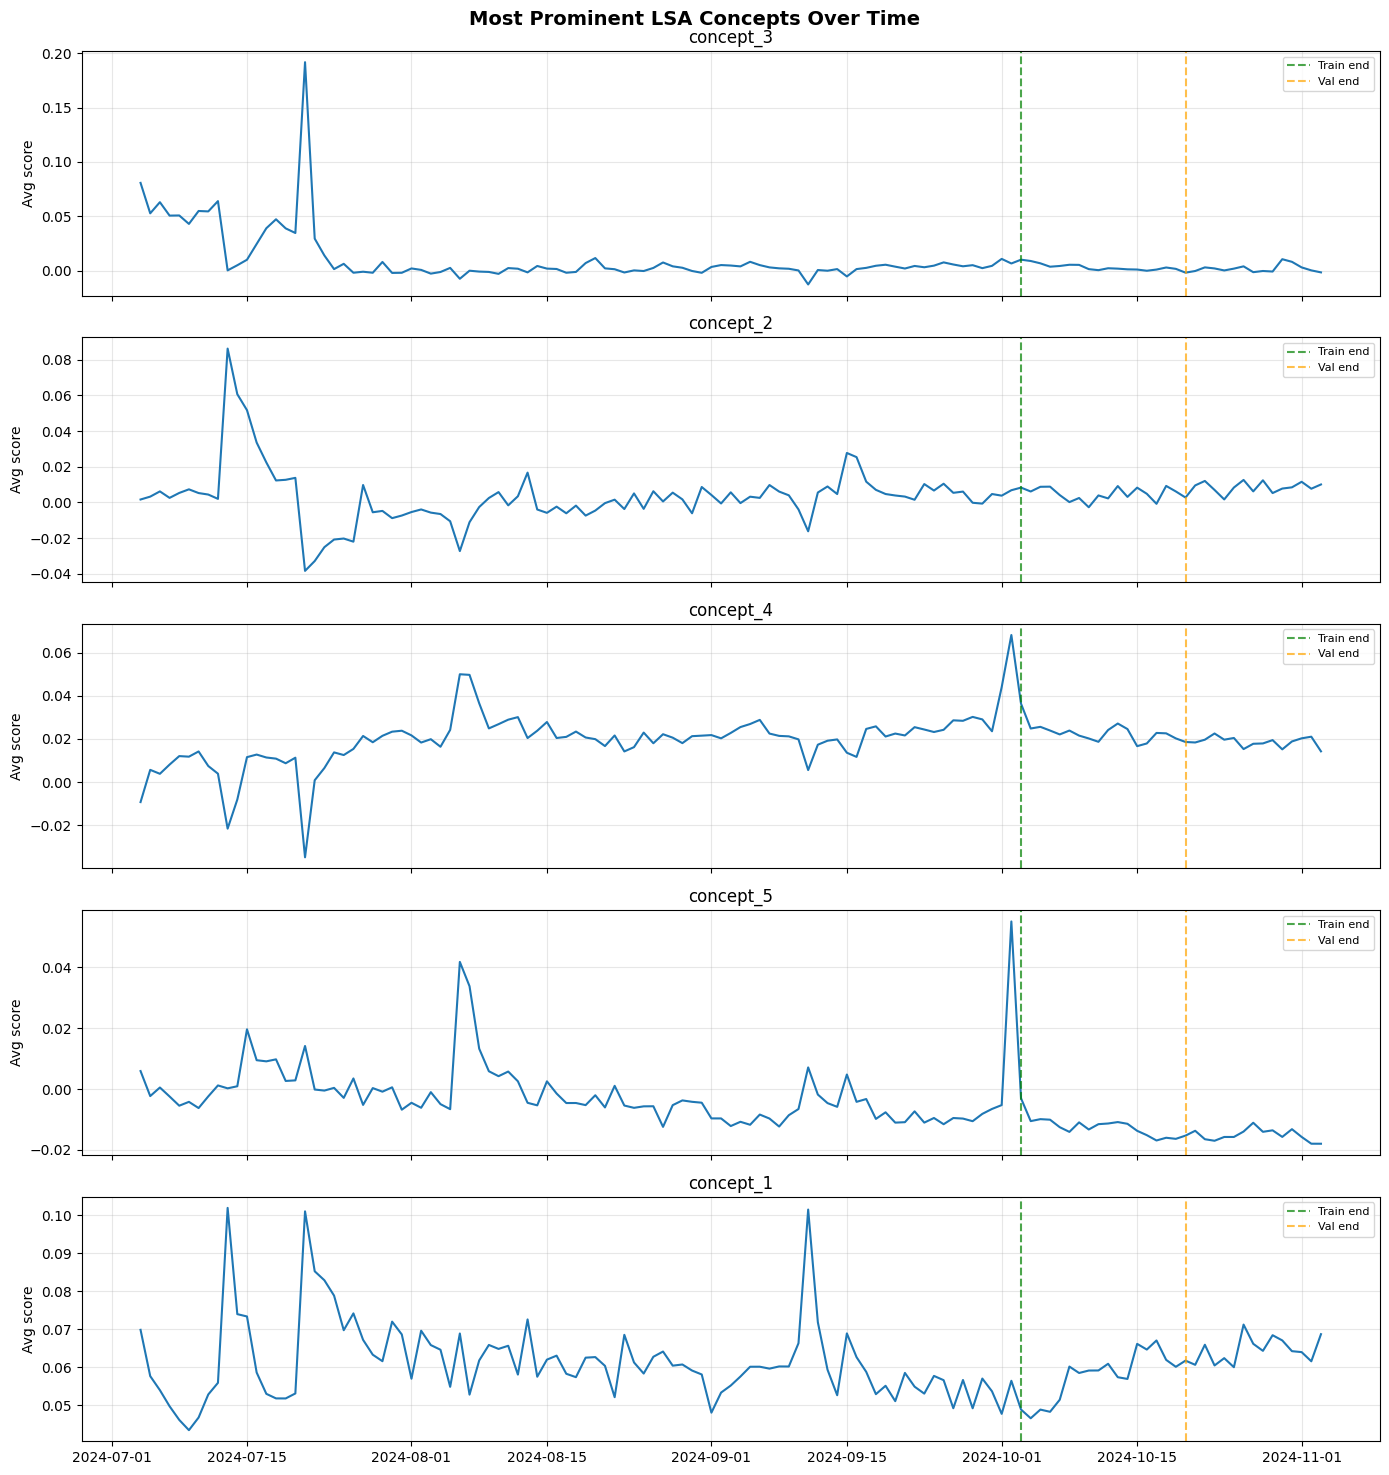

Top terms per concept:

concept_3: biden, joe, race, kamala, presidential, drops, harris, trump, election, president

concept_2: trump, kamala, harris, donald, rally, biden, assassination, attempt, walz, endorses

concept_4: vance, says, election, walz, us, jd, israel, biden, tim, trump

concept_5: vance, election, jd, walz, tim, us, debate, vp, israel, biden

concept_1: trump, harris, kamala, donald, biden, election, says, president, campaign, debate


In [100]:
# ── Add date back to LSA matrix ───────────────────────────────────────────────
lsa_cols = [f'concept_{i+1}' for i in range(n_components_optimal)]

lsa_df = pd.DataFrame(documents_lsa, columns=lsa_cols, index=df_combined.index)
lsa_df['date'] = df_combined['date'].values

# ── Average concept scores per day ────────────────────────────────────────────
daily_concepts = lsa_df.groupby('date')[lsa_cols].mean()

# ── Plot top N most prominent concepts over time ──────────────────────────────
# Find top 5 concepts by overall variance (most "active" over time)
top_n = 5
top_concepts = daily_concepts.var().nlargest(top_n).index.tolist()

fig, axes = plt.subplots(top_n, 1, figsize=(14, 3 * top_n), sharex=True)

for ax, concept in zip(axes, top_concepts):
    ax.plot(daily_concepts.index, daily_concepts[concept], linewidth=1.5)
    ax.axvline(pd.Timestamp('2024-10-03'), color='green',  linestyle='--', alpha=0.7, label='Train end')
    ax.axvline(pd.Timestamp('2024-10-20'), color='orange', linestyle='--', alpha=0.7, label='Val end')
    ax.set_ylabel('Avg score')
    ax.set_title(concept)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Most Prominent LSA Concepts Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print top terms per concept for interpretation ────────────────────────────
feature_names = vectorizer.get_feature_names_out()

print("Top terms per concept:")
for concept in top_concepts:
    idx = int(concept.split('_')[1]) - 1
    component = lsa.components_[idx]
    top_terms = [feature_names[i] for i in np.argsort(np.abs(component))[::-1][:10]]
    print(f"\n{concept}: {', '.join(top_terms)}")

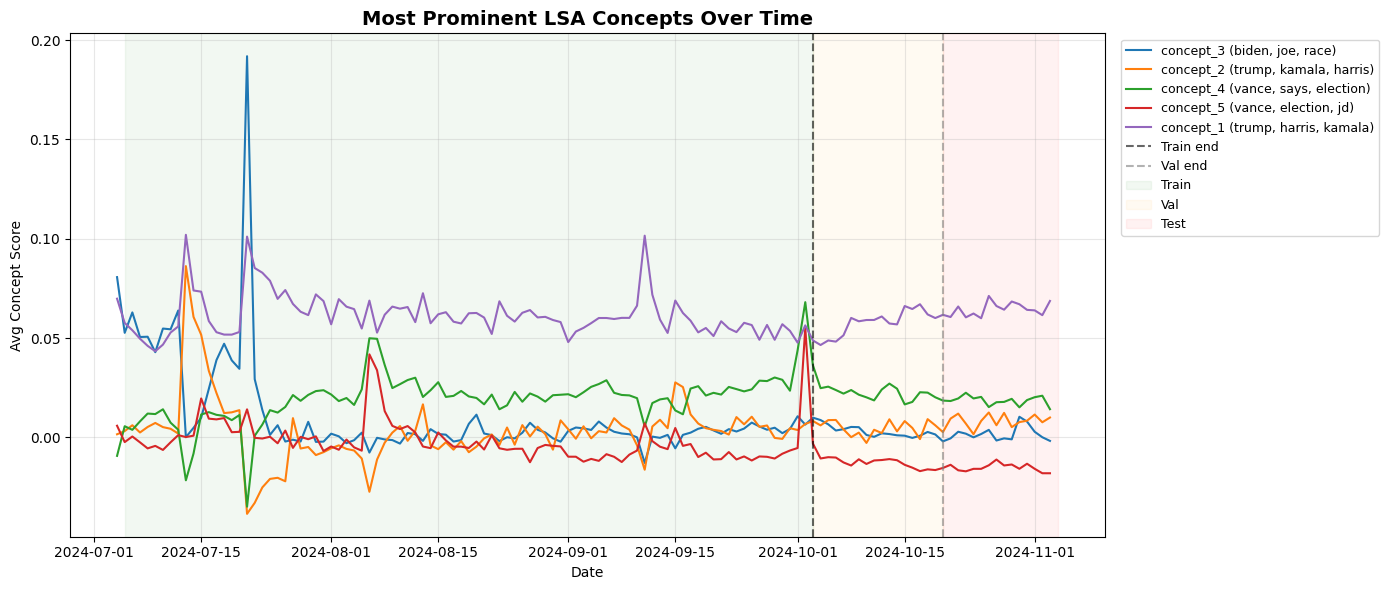

In [101]:
# ── Plot all top concepts on ONE graph ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10(range(top_n))

for concept, color in zip(top_concepts, colors):
    idx        = int(concept.split('_')[1]) - 1
    component  = lsa.components_[idx]
    top_terms  = [feature_names[i] for i in np.argsort(np.abs(component))[::-1][:5]]
    label      = f"{concept} ({', '.join(top_terms[:3])})"  # show top 3 terms in legend
    
    ax.plot(daily_concepts.index, daily_concepts[concept],
            linewidth=1.5, color=color, label=label)

# Train/val/test boundaries
ax.axvline(pd.Timestamp('2024-10-03'), color='black', linestyle='--', alpha=0.6, label='Train end')
ax.axvline(pd.Timestamp('2024-10-20'), color='gray',  linestyle='--', alpha=0.6, label='Val end')

# Shade regions
ax.axvspan(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-10-03'), alpha=0.05, color='green',  label='Train')
ax.axvspan(pd.Timestamp('2024-10-03'), pd.Timestamp('2024-10-20'), alpha=0.05, color='orange', label='Val')
ax.axvspan(pd.Timestamp('2024-10-20'), pd.Timestamp('2024-11-04'), alpha=0.05, color='red',    label='Test')

ax.set_xlabel('Date')
ax.set_ylabel('Avg Concept Score')
ax.set_title('Most Prominent LSA Concepts Over Time', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

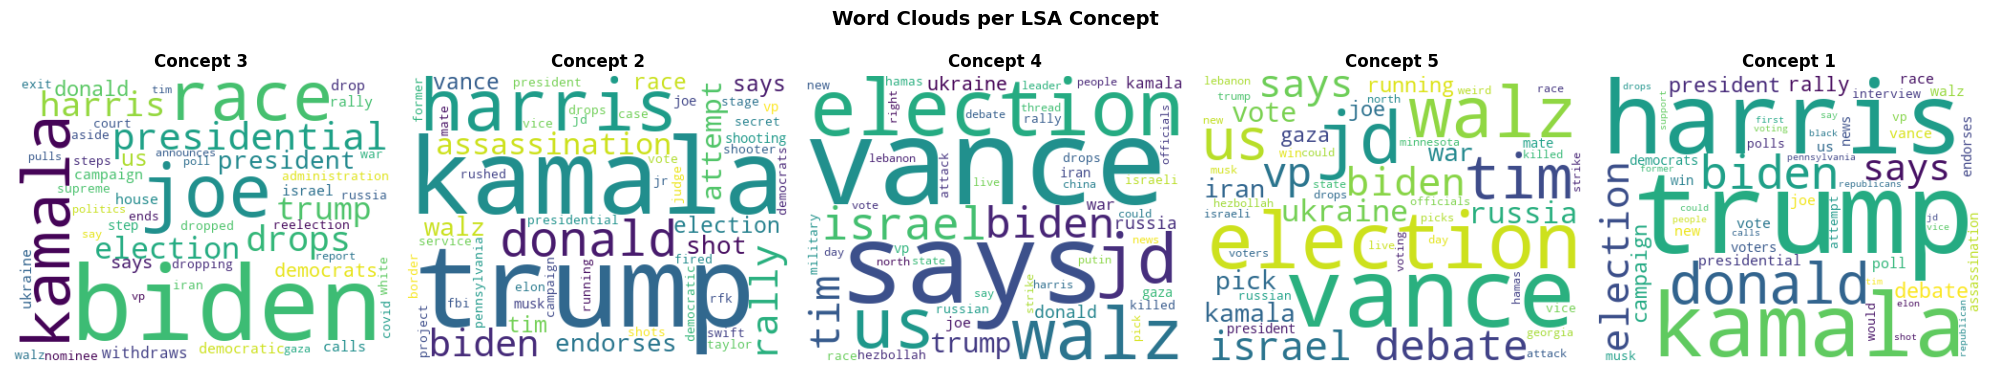

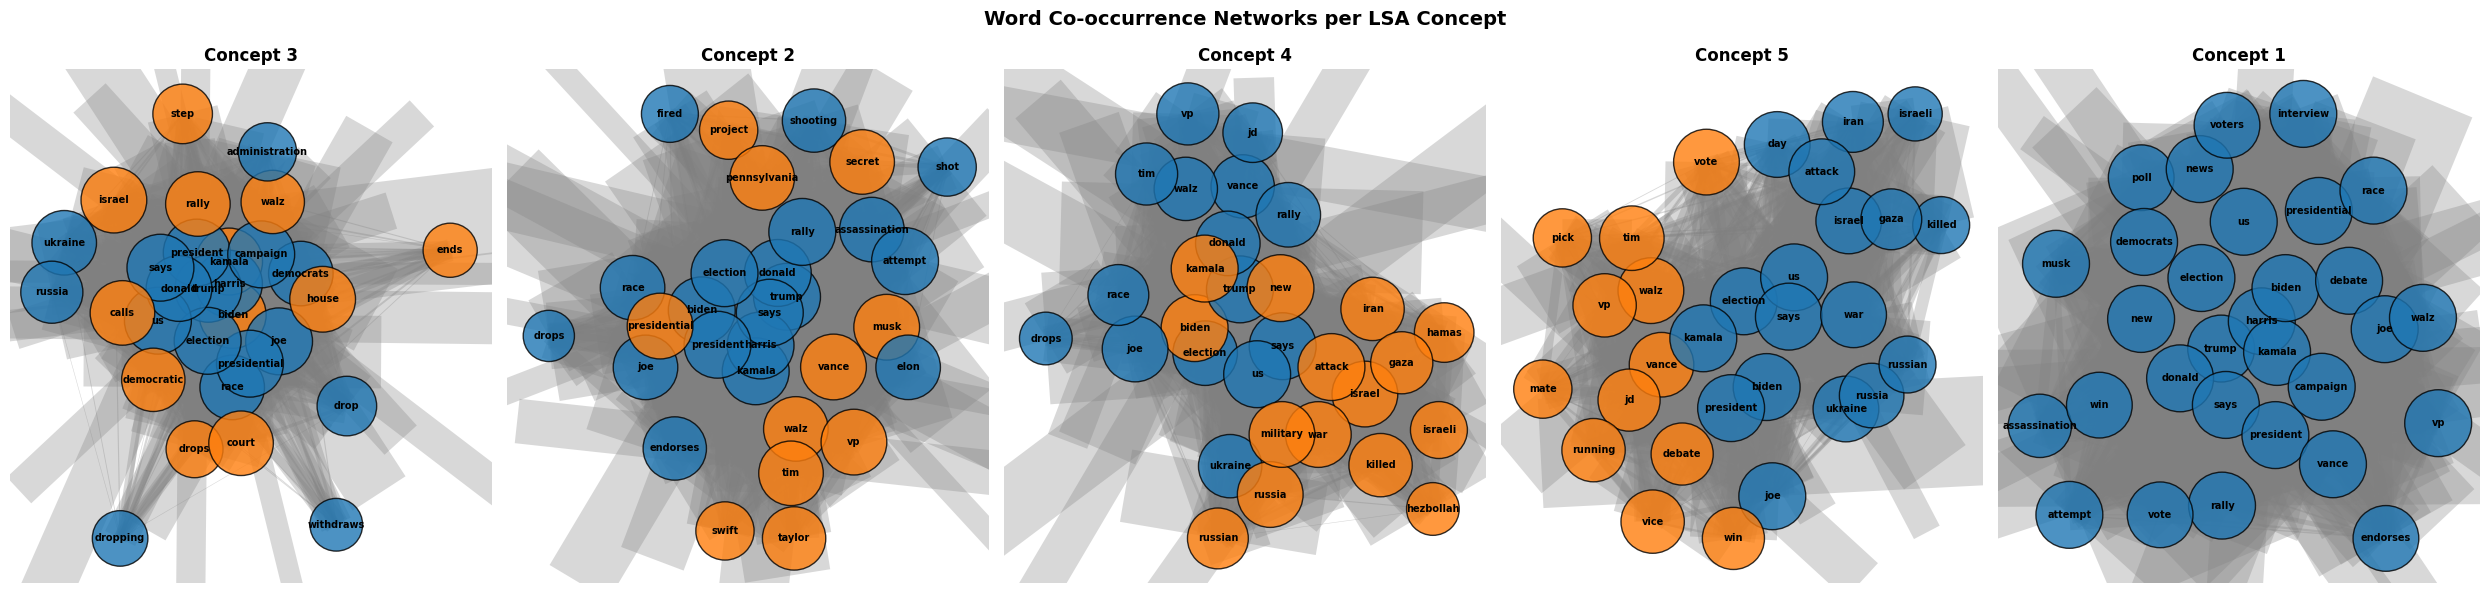

In [103]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
from networkx.algorithms import community
from collections import Counter

# ── Helper: get top terms + weights per concept ───────────────────────────────
def get_concept_terms(concept_idx, n_top=50):
    """Returns {term: abs_weight} dict for a concept — used for word cloud."""
    component = lsa.components_[concept_idx]
    top_idx   = np.argsort(np.abs(component))[::-1][:n_top]
    return {feature_names[i]: abs(component[i]) for i in top_idx}

# ── 1. WORD CLOUDS per concept (lecture style: weighted by LSA loadings) ───────
n_concepts_to_show = 5
top_concepts_idx = [int(c.split('_')[1]) - 1 for c in top_concepts]  # from earlier

fig, axes = plt.subplots(1, n_concepts_to_show, figsize=(20, 4))

for ax, concept_idx in zip(axes, top_concepts_idx):
    term_weights = get_concept_terms(concept_idx, n_top=50)
    
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5
    ).generate_from_frequencies(term_weights)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Concept {concept_idx+1}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds per LSA Concept', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. WORD NETWORKS per concept (lecture style: co-occurrence network) ────────
def build_concept_network(concept_idx, n_top_terms=30, min_cooccur=2):
    """Build co-occurrence network for the top terms of a concept."""
    
    # Step 1: get top terms for this concept
    component  = lsa.components_[concept_idx]
    top_idx    = np.argsort(np.abs(component))[::-1][:n_top_terms]
    top_terms  = [feature_names[i] for i in top_idx]
    
    # Step 2: binary DTM restricted to these terms (lecture approach)
    binary_vec = CountVectorizer(
        vocabulary=top_terms,   # only the concept's top terms
        binary=True
    )
    dtm_binary = binary_vec.fit_transform(df_combined['text_clean'])
    terms      = binary_vec.get_feature_names_out()
    
    # Step 3: co-occurrence matrix C = D^T × D (lecture formula)
    cooccur = (dtm_binary.T @ dtm_binary).toarray()
    np.fill_diagonal(cooccur, 0)  # remove self-loops
    
    # Step 4: build graph
    G = nx.Graph()
    for i, t_i in enumerate(terms):
        for j, t_j in enumerate(terms):
            if i < j and cooccur[i, j] >= min_cooccur:
                G.add_edge(t_i, t_j, weight=cooccur[i, j])
    
    return G, terms

fig, axes = plt.subplots(1, n_concepts_to_show, figsize=(25, 6))

for ax, concept_idx in zip(axes, top_concepts_idx):
    G, terms = build_concept_network(concept_idx, n_top_terms=30, min_cooccur=2)
    
    if G.number_of_nodes() == 0:
        ax.set_title(f'Concept {concept_idx+1}\n(no edges)')
        ax.axis('off')
        continue
    
    # Community detection (lecture style)
    communities   = community.greedy_modularity_communities(G)
    community_map = {node: i for i, comm in enumerate(communities) for node in comm}
    colors        = plt.cm.tab10(range(len(communities)))
    node_colors   = [colors[community_map[n]] for n in G.nodes()]
    
    # Layout + draw
    pos         = nx.spring_layout(G, k=1.5, seed=42)
    node_sizes  = [G.degree(n) * 80 for n in G.nodes()]
    edge_widths = [G[u][v]['weight'] / 5 for u, v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=node_colors, alpha=0.8,
                           edgecolors='black', linewidths=1)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                           alpha=0.3, edge_color='gray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
    
    ax.set_title(f'Concept {concept_idx+1}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Co-occurrence Networks per LSA Concept', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# predictive setup --> create basetable for concatenation and feature engineering (train test split)

In [105]:
df_combined.dtypes

author                         object
created_utc                     int64
num_comments                    int64
score                           int64
upvote_ratio                  float64
num_crossposts                  int64
title                          object
timestamp         datetime64[ns, UTC]
date                           object
text_clean                     object
words                          object
word_count                      int64
dtype: object

In [106]:
df_combined['date'] = pd.to_datetime(df_combined['date'])

train_mask = (df_combined['date'] >= '2024-07-05')  & (df_combined['date'] <= '2024-10-03')
val_mask   = (df_combined['date'] >= '2024-10-04') & (df_combined['date'] <= '2024-10-20')
test_mask  = (df_combined['date'] >= '2024-10-21') & (df_combined['date'] <= '2024-11-04')

train_df = df_combined[train_mask].copy()
val_df   = df_combined[val_mask].copy()
test_df  = df_combined[test_mask].copy()

print(f"Train : {len(train_df)} posts ({train_df['date'].min()} → {train_df['date'].max()})")
print(f"Val   : {len(val_df)} posts ({val_df['date'].min()} → {val_df['date'].max()})")
print(f"Test  : {len(test_df)} posts ({test_df['date'].min()} → {test_df['date'].max()})")

Train : 112503 posts (2024-07-05 00:00:00 → 2024-10-03 00:00:00)
Val   : 16537 posts (2024-10-04 00:00:00 → 2024-10-20 00:00:00)
Test  : 19073 posts (2024-10-21 00:00:00 → 2024-11-03 00:00:00)


In [108]:
train_df.head(1)

,author,created_utc,num_comments,score,upvote_ratio,num_crossposts,title,timestamp,date,text_clean,words,word_count
0,Ask4MD,1720137838,0,1,1.0,0,Good Question…,2024-07-05 00:03:58+00:00,2024-07-05,good question,"[good, question]",2
